<a href="https://colab.research.google.com/github/Pranjalits/Machine_Learning/blob/main/Deep_Learning_with_PyTorch_Siamese_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install segmentation-models-pytorch
!pip install -U git+https://github.com/albumentations-team/albumentations
!pip install --upgrade opencv-contrib-python

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.3/121.3 kB 10.6 MB/s eta 0:00:00
  Created wheel for efficientnet-pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16424 sha256=32245fda27cf2deb0f623492d8938a085613e3b5bfbb592caf9433231a0ac41b
  Stored in directory: /root/.cache/pip/wheels/03/3f/e9/911b1bc46869644912bda90a56bcf7b960f20b5187feea3baf
  Created wheel for pretrainedmodels: filename=pretrainedmodels-0.7.4-py3-none-any.whl size=60944 sha256=0915797ebbfe221d616247df72528794b6e1ed434ba3d9fb8a674073f4bee4d8
  Stored in directory: /root/.cache/pip/wheels/35/cb/a5/8f534c60142835bfc889f9a482e4a67e0b817032d9c6883b64
Successfully built efficientnet-pytorch pretrainedmodels
  Cloning https://github.com/albumentations-team/albumentations to /tmp/pip-req-build-agbvy22e
  Running command git clone --filter=blob:n

# Download Full Dataset

Market-1501 dataset :
https://www.kaggle.com/pengcw1/market-1501

In [2]:
!git clone https://github.com/parth1620/Person-Re-Id-Dataset

Cloning into 'Person-Re-Id-Dataset'...
remote: Enumerating objects: 12942, done.
remote: Counting objects: 100% (12942/12942), done.
remote: Compressing objects: 100% (12942/12942), done.
remote: Total 12942 (delta 0), reused 12942 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (12942/12942), 27.68 MiB | 15.67 MiB/s, done.


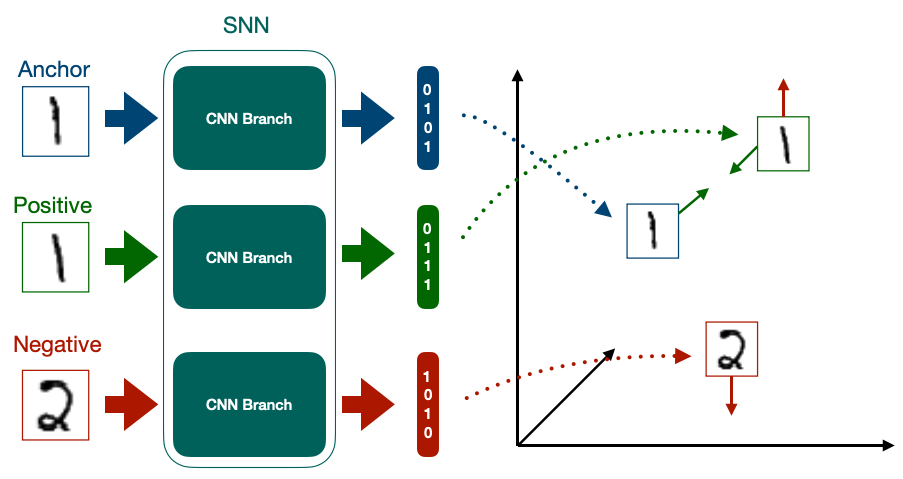

# Imports

In [3]:
import sys
sys.path.append('/content/Person-Re-Id-Dataset')

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import timm

import torch.nn.functional as F
from torch import nn
from torch.utils.data import Dataset, DataLoader

from skimage import io
from sklearn.model_selection import train_test_split

from tqdm import tqdm

# Configurations

In [5]:
data_dir = '/content/Person-Re-Id-Dataset/train/'
csv_file = '/content/Person-Re-Id-Dataset/train.csv'
batch_size = 32
lr = 0.001
epochs = 15
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [6]:
df = pd.read_csv(csv_file)
df.head()

,Anchor,Negative,Positive
0,1420_c5s3_052165_01.jpg,1334_c6s3_061492_05.jpg,1420_c3s3_051678_01.jpg
1,1420_c3s3_061978_03.jpg,0234_c3s3_079494_02.jpg,1420_c6s3_085567_02.jpg
2,1420_c5s3_062565_05.jpg,0475_c2s1_122816_08.jpg,1420_c3s3_051653_01.jpg
3,1420_c6s3_085592_04.jpg,0662_c2s2_036662_05.jpg,1420_c1s6_013446_04.jpg
4,0663_c5s3_085987_03.jpg,1463_c2s3_098102_02.jpg,0663_c3s3_085544_06.jpg


In [7]:
row = df.iloc[4]
a_img = io.imread(data_dir + row.Anchor)
p_img = io.imread(data_dir + row.Positive)
n_img = io.imread(data_dir + row.Negative)

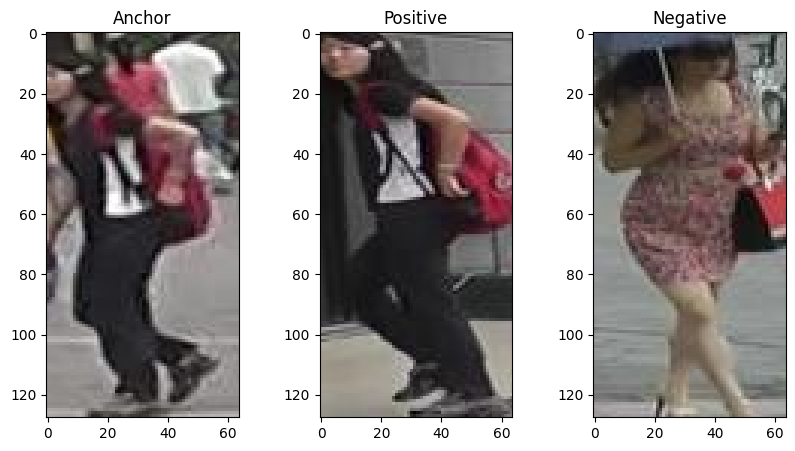

In [8]:
f, (ax1, ax2, ax3) = plt.subplots(1,3,figsize= (10,5))

ax1.set_title('Anchor')
ax1.imshow(a_img)

ax2.set_title('Positive')
ax2.imshow(p_img)

ax3.set_title('Negative')
ax3.imshow(n_img)

In [9]:
train_df, valid_df = train_test_split(df, test_size = 0.2, random_state = 42)

# Create APN Dataset

In [11]:
class apn_dataset(Dataset):
  def __init__(self, df):
    self.df = df

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    row = self.df.iloc[idx]

    a_img = io.imread(data_dir + row.Anchor)
    p_img = io.imread(data_dir + row.Positive)
    n_img = io.imread(data_dir + row.Negative)

    a_img = torch.from_numpy(a_img).permute(2,0,1)/255.0
    p_img = torch.from_numpy(p_img).permute(2,0,1)/255.0
    n_img = torch.from_numpy(n_img).permute(2,0,1)/255.0

    return a_img, p_img, n_img

In [12]:
trainset = apn_dataset(train_df)
validset = apn_dataset(valid_df)

print(f"Length of trainset : {len(trainset)}")
print(f"Length of validset : {len(validset)}")

Length of trainset : 3200
Length of validset : 800


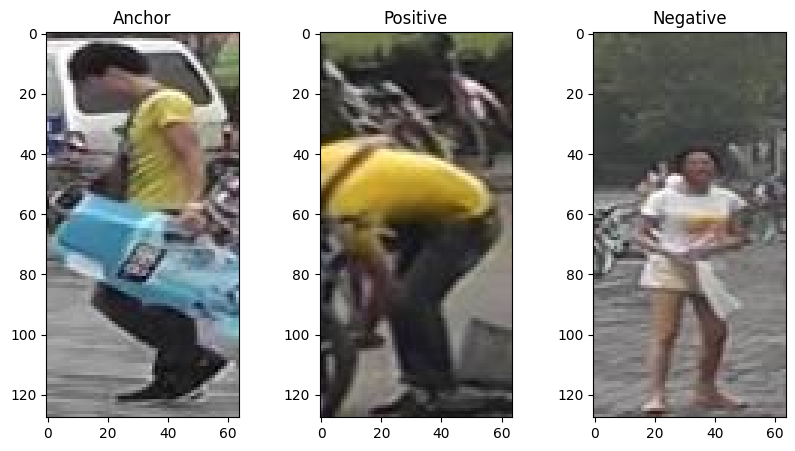

In [13]:
idx = 40
A,P,N = trainset[idx]

f, (ax1, ax2, ax3) = plt.subplots(1,3,figsize= (10,5))

ax1.set_title('Anchor')
ax1.imshow(A.numpy().transpose((1,2,0)), cmap = 'gray')

ax2.set_title('Positive')
ax2.imshow(P.numpy().transpose((1,2,0)), cmap = 'gray')

ax3.set_title('Negative')
ax3.imshow(N.numpy().transpose((1,2,0)), cmap = 'gray')

# Load Dataset into Batches

In [14]:
trainloader = DataLoader(trainset, batch_size = batch_size, shuffle = True)
validloader = DataLoader(validset, batch_size = batch_size, shuffle = True)

In [15]:
print(f"No. of batches in trainloader : {len(trainloader)}")
print(f"No. of batches in validloader : {len(validloader)}")

No. of batches in trainloader : 100
No. of batches in validloader : 25


In [16]:
for A,P,N in trainloader:
  break;

print(f"One image batch shape : {A.shape}")

One image batch shape : torch.Size([32, 3, 128, 64])


# Create Model

In [17]:
class apn_model(nn.Module):
  def __init__(self, emb_size = 512):
    super(apn_model, self).__init__()
    self.efficientnet = timm.create_model('efficientnet_b0', pretrained = True)
    self.efficientnet.classifier = nn.Linear(in_features = self.efficientnet.classifier.in_features, out_features = emb_size)

  def forward(self, x):
    x = self.efficientnet(x)
    return x

In [18]:
model = apn_model()
model.to(device)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

apn_model(
  (efficientnet): EfficientNet(
    (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn1): BatchNormAct2d(
            32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )
          (conv_pw):

# Create Train and Eval function

In [20]:
def train_fn(model, dataloader, optimizer, criterion):
  model.train()
  total_loss = 0.0
  for A,P,N in tqdm(dataloader):
    A = A.to(device)
    P = P.to(device)
    N = N.to(device)
    a_embs = model(A)
    p_embs = model(P)
    n_embs = model(N)

    loss = criterion(a_embs, p_embs, n_embs)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  return total_loss/len(dataloader)

In [21]:
def eval_fn(model, dataloader, criterion):
  model.eval()
  total_loss = 0.0

  with torch.no_grad():
    for A,P,N in tqdm(dataloader):
      A = A.to(device)
      P = P.to(device)
      N = N.to(device)
      a_embs = model(A)
      p_embs = model(P)
      n_embs = model(N)

      loss = criterion(a_embs, p_embs, n_embs)

      total_loss += loss.item()

    return total_loss/len(dataloader)

In [24]:
criterion = nn.TripletMarginLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = lr)

# Create Training Loop

In [25]:
best_valid_loss = np.Inf

for i in range(epochs):
  train_loss = train_fn(model, trainloader, optimizer, criterion)
  valid_loss = eval_fn(model, validloader, criterion)
  if valid_loss < best_valid_loss:
    best_valid_loss = valid_loss
    torch.save(model.state_dict(), 'best_model.pt')
    best_valid_loss = valid_loss
    print("saved_Weight_success")
  print(f"epochs : {i+1} trainloss : {train_loss} valid_loss: {valid_loss}")

100%|██████████| 25/25 [00:03<00:00,  6.75it/s]


saved_Weight_success
epochs : 1 trainloss : 0.6176486769318581 valid_loss: 0.5908856165409088


100%|██████████| 25/25 [00:03<00:00,  6.77it/s]


saved_Weight_success
epochs : 2 trainloss : 0.35862492755055425 valid_loss: 0.3236819648742676


100%|██████████| 25/25 [00:04<00:00,  5.54it/s]


...

epochs : 13 trainloss : 0.0435169218480587 valid_loss: 0.185188450217247


100%|██████████| 25/25 [00:03<00:00,  6.97it/s]


saved_Weight_success
epochs : 14 trainloss : 0.048693927526474 valid_loss: 0.13755502164363861


100%|██████████| 25/25 [00:04<00:00,  5.34it/s]

epochs : 15 trainloss : 0.021940726563334467 valid_loss: 0.14080731868743895


# Get Anchor Embeddings

In [31]:
def get_encoding_csv(model, anc_img_names):
  anc_img_names_arr = np.array(anc_img_names)
  encodings = []

  model.eval()
  with torch.no_grad():
    for img_name in tqdm(anc_img_names_arr):
      img = io.imread(data_dir + img_name)
      img = torch.from_numpy(img).permute(2,0,1)/255.0
      img = img.to(device)
      img_enc = model(img.unsqueeze(0))
      encodings.append(img_enc.squeeze().cpu().numpy())

    encodings = np.array(encodings)
    encodings = pd.DataFrame(encodings)
    df_enc = pd.concat([anc_img_names, encodings], axis = 1)
  return df_enc

In [32]:
model.load_state_dict(torch.load('best_model.pt'))
df_enc = get_encoding_csv(model, df['Anchor'])

<ipython-input-32-fb78bba7c639>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pt'))
100%|██████████| 4000/4000 [00:56<00:00, 

In [33]:
df_enc.to_csv('df_enc.csv', index = False)
df_enc.head()

,Anchor,0,1,2,3,4,5,6,7,8,...,502,503,504,505,506,507,508,509,510,511
0,1420_c5s3_052165_01.jpg,0.466648,0.037503,-1.151489,0.349893,-1.013205,-0.753346,0.099793,0.007646,-0.530767,...,0.652757,-0.481842,-0.241377,0.777382,0.360333,0.809665,0.578807,0.489088,-0.377293,0.334192
1,1420_c3s3_061978_03.jpg,0.608973,-0.045654,-1.283612,0.021090,-0.913584,-0.502366,0.067981,0.321806,-0.737362,...,0.734422,-0.597341,-0.377581,0.560693,0.542858,0.827166,0.430654,0.445388,-0.251814,0.125171
2,1420_c5s3_062565_05.jpg,0.321446,0.062870,-1.033191,0.307571,-0.681793,-0.674919,-0.032998,0.056533,-0.111367,...,0.360508,-0.554418,-0.121041,0.898781,0.104517,0.977246,0.778643,0.618201,-0.628766,0.529072
3,1420_c6s3_085592_04.jpg,0.488337,-0.033400,-1.128252,0.354432,-0.762607,-0.440025,0.091520,0.130624,-0.656344,...,0.696957,-0.403273,-0.229402,0.698234,0.331377,0.597863,0.501699,0.206941,-0.281171,0.240633
4,0663_c5s3_085987_03.jpg,0.127775,-0.370096,0.005174,0.514572,0.086922,0.133246,-0.292938,-0.239357,-0.310345,...,-0.361889,-0.339574,-0.020004,0.608239,-0.785983,-0.379650,0.166860,0.054380,-0.209148,0.457037


# Inference

In [69]:
def euclidean_distance(img_enc, anc_enc_arr):
  distance = np.sqrt(np.dot(img_enc - anc_enc_arr, (img_enc - anc_enc_arr).T))
  return distance

In [70]:
idx = 0
img_name = df_enc['Anchor'].iloc[idx]
img_path = data_dir + img_name
img = io.imread(data_dir + img_name)
img = torch.from_numpy(img).permute(2,0,1)/255.0
model.eval()
with torch.no_grad():
  img = img.to(device)
  img_enc = model(img.unsqueeze(0))
  img_enc = img_enc.squeeze().cpu().numpy()

In [71]:
anc_enc_arr = df_enc.iloc[:,1:].to_numpy()
anc_img_names = df_enc['Anchor']

In [75]:
distance = []

for i in range(anc_enc_arr.shape[0]):
  dist = euclidean_distance(img_enc, anc_enc_arr[i : i+1 , :])
  distance = np.append(distance, dist)

In [76]:
closest_idx = np.argsort(distance)

/usr/local/lib/python3.10/dist-packages/networkx/drawing/layout.py:728: RuntimeWarning: divide by zero encountered in divide
  costargs = (np, 1 / (dist_mtx + np.eye(dist_mtx.shape[0]) * 1e-3), meanwt, dim)


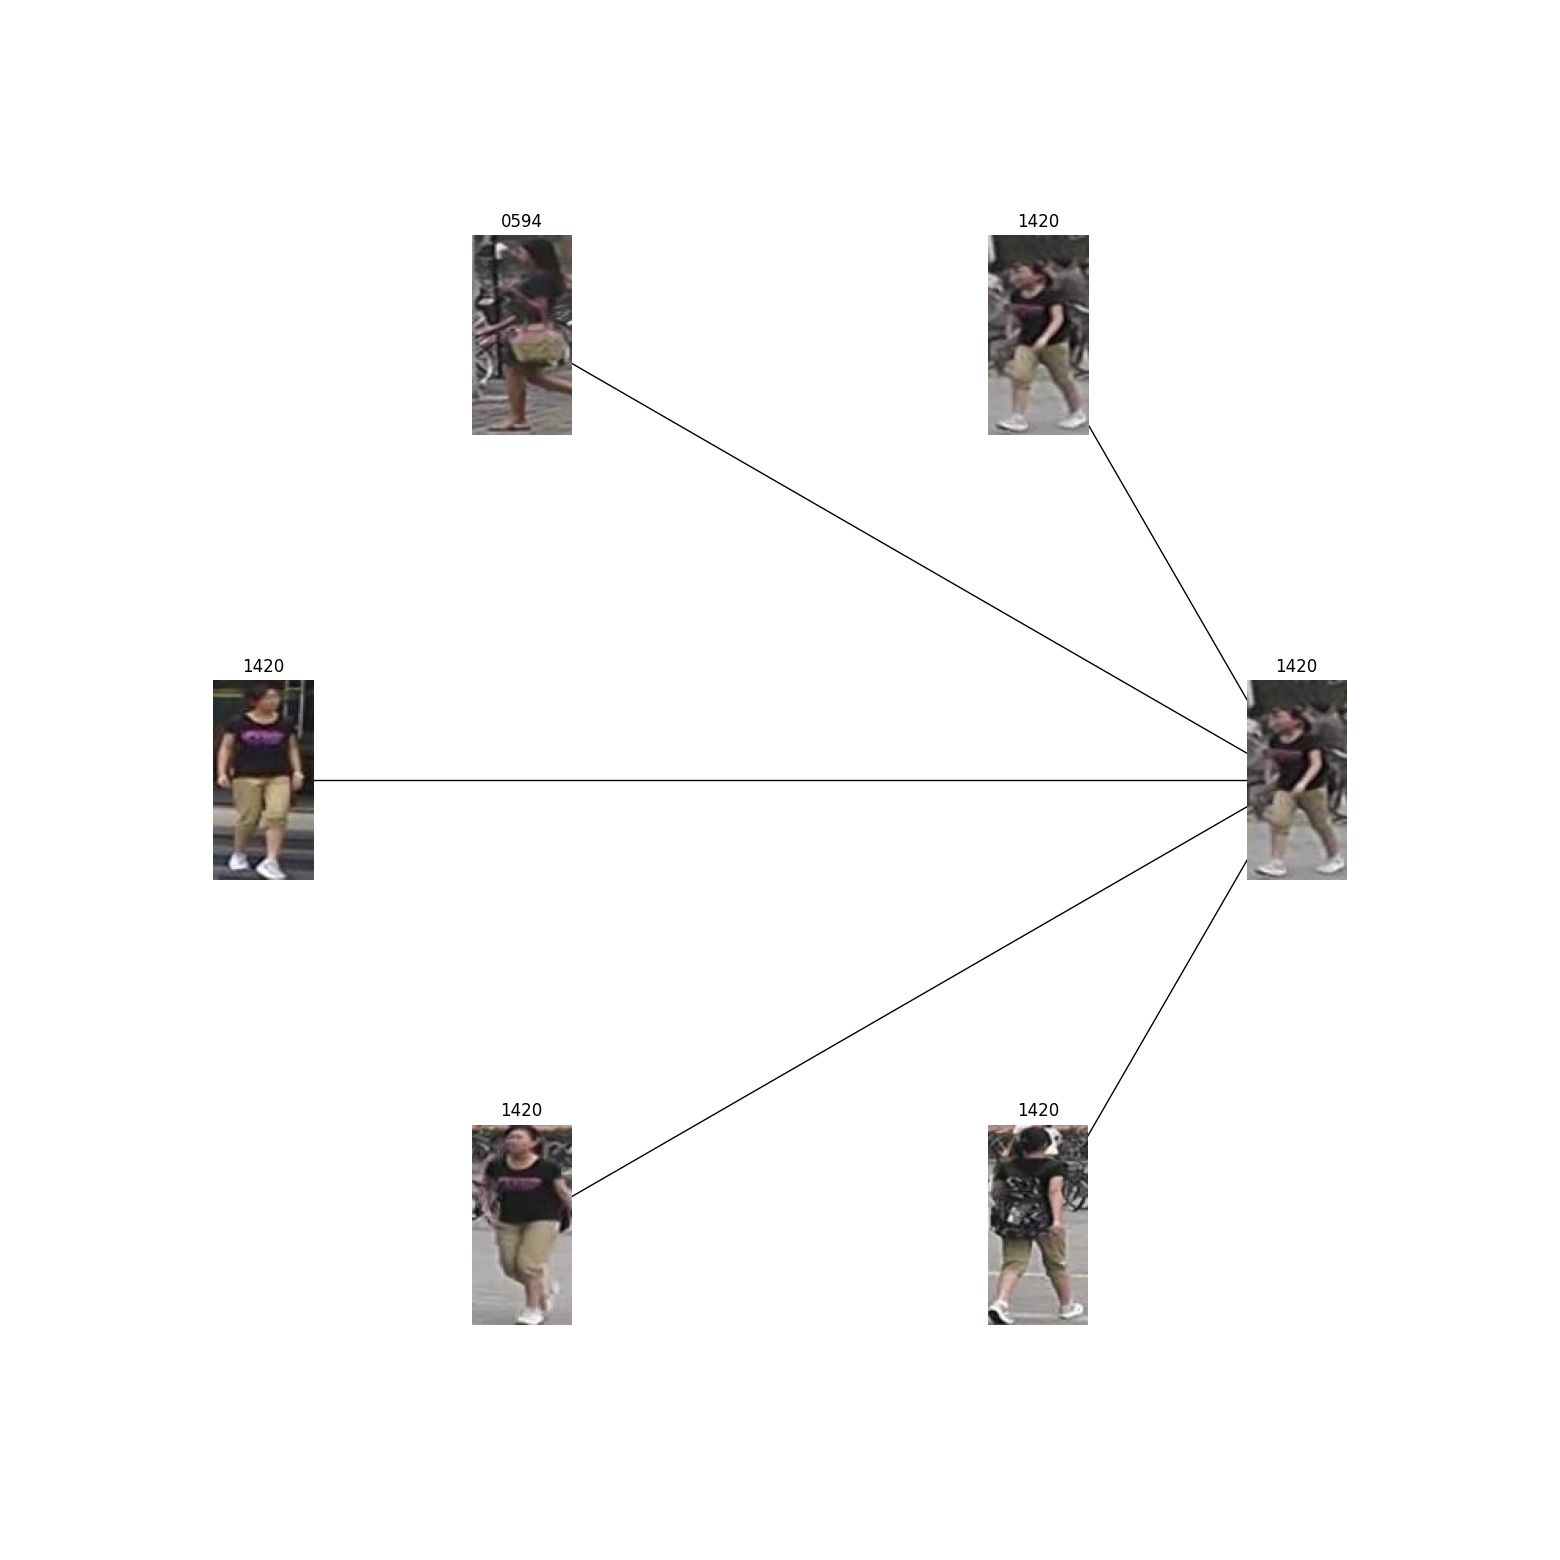

In [77]:
from utils import plot_closest_imgs
plot_closest_imgs(anc_img_names, data_dir, img, img_path, closest_idx, distance, no_of_closest = 5 )